In [ ]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, random_split
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import wandb
import zipfile

In [ ]:
wandb.init(project="intel-resnet18", name="resnet18-adamw")
#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

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

 1


wandb: You chose 'Create a W&B account'
wandb: Create an account here: https://wandb.ai/authorize?signup=true&ref=models
wandb: After creating your account, create a new API key and store it securely.
wandb: Paste your API key and hit enter:

 ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: ramprasad-nitr (ramprasad-nitr-iit-bhubaneswar) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import zipfile
# Dataset: https://www.kaggle.com/datasets/tamimresearch/weather-image-dataset
zip_path = "/content/drive/MyDrive/Courses/ML_DL Datasets/Intel_Image_Classification.zip"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("/content/data")

In [ ]:
train_dir = "/content/data/seg_train/seg_train"
test_dir  = "/content/data/seg_test/seg_test"

In [ ]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [ ]:
full_train_dataset = datasets.ImageFolder(train_dir, transform=transform)

train_size = int(0.8 * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size

train_dataset, val_dataset = random_split(full_train_dataset, [train_size, val_size])

test_dataset = datasets.ImageFolder(test_dir, transform=transform)

In [ ]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=32, shuffle=False)

class_names = full_train_dataset.classes
num_classes = len(class_names)

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = models.resnet18(pretrained=True)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 169MB/s]


In [ ]:
print(model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [ ]:
for param in model.parameters():
    param.requires_grad = True

model.fc = nn.Linear(model.fc.in_features, num_classes)

In [ ]:
nn.init.xavier_uniform_(model.fc.weight)

model = model.to(device)

In [ ]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.AdamW(model.fc.parameters(), lr=0.001)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.1, patience=10
)

In [ ]:
def train_model(model, epochs=10):
    best_val_loss = float('inf')

    for epoch in range(epochs):
        model.train()
        train_loss=0
        correct=0
        total=0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

        train_acc = correct / total
        model.eval()
        val_loss = 0
        correct = 0
        total = 0

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)

                outputs = model(images)
                loss = criterion(outputs, labels)

                val_loss += loss.item()

                _, preds = torch.max(outputs, 1)
                correct += (preds == labels).sum().item()
                total += labels.size(0)
        val_acc = correct / total

        train_loss /= len(train_loader)
        val_loss /= len(val_loader)

        scheduler.step(val_loss)

        print(f"Epoch [{epoch+1}/{epochs}]")
        print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
        print(f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

        wandb.log({
            "train_loss": train_loss,
            "train_accuracy": train_acc,
            "val_loss": val_loss,
            "val_accuracy": val_acc
        })

In [ ]:
train_model(model, epochs=10)

Epoch [1/10]
Train Loss: 0.6229 | Train Acc: 0.7715
Val Loss: 0.3032 | Val Acc: 0.8885
Epoch [2/10]
Train Loss: 0.3525 | Train Acc: 0.8727
Val Loss: 0.2609 | Val Acc: 0.9084
Epoch [3/10]
Train Loss: 0.3125 | Train Acc: 0.8883
Val Loss: 0.2470 | Val Acc: 0.9149
Epoch [4/10]
Train Loss: 0.2901 | Train Acc: 0.8928
Val Loss: 0.2368 | Val Acc: 0.9170
Epoch [5/10]
Train Loss: 0.2802 | Train Acc: 0.8983
Val Loss: 0.2320 | Val Acc: 0.9209
Epoch [6/10]
Train Loss: 0.2682 | Train Acc: 0.9010
Val Loss: 0.2329 | Val Acc: 0.9195
Epoch [7/10]
Train Loss: 0.2612 | Train Acc: 0.9042
Val Loss: 0.2402 | Val Acc: 0.9188
Epoch [8/10]
Train Loss: 0.2629 | Train Acc: 0.9046
Val Loss: 0.2294 | Val Acc: 0.9213
Epoch [9/10]
Train Loss: 0.2539 | Train Acc: 0.9035
Val Loss: 0.2344 | Val Acc: 0.9170


In [ ]:
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)

        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())


Classification Report:
              precision    recall  f1-score   support

   buildings       0.88      0.93      0.90       437
      forest       0.99      0.99      0.99       474
     glacier       0.81      0.87      0.84       553
    mountain       0.87      0.79      0.83       525
         sea       0.94      0.96      0.95       510
      street       0.94      0.89      0.91       501

    accuracy                           0.90      3000
   macro avg       0.90      0.90      0.90      3000
weighted avg       0.90      0.90      0.90      3000



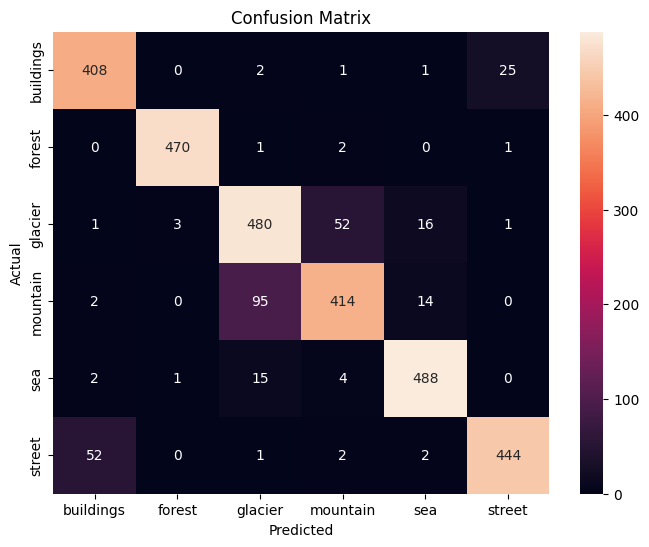

In [ ]:
print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=class_names))

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
report = classification_report(all_labels, all_preds, output_dict=True)

wandb.log({
    "precision": report["weighted avg"]["precision"],
    "recall": report["weighted avg"]["recall"],
    "f1_score": report["weighted avg"]["f1-score"]
})

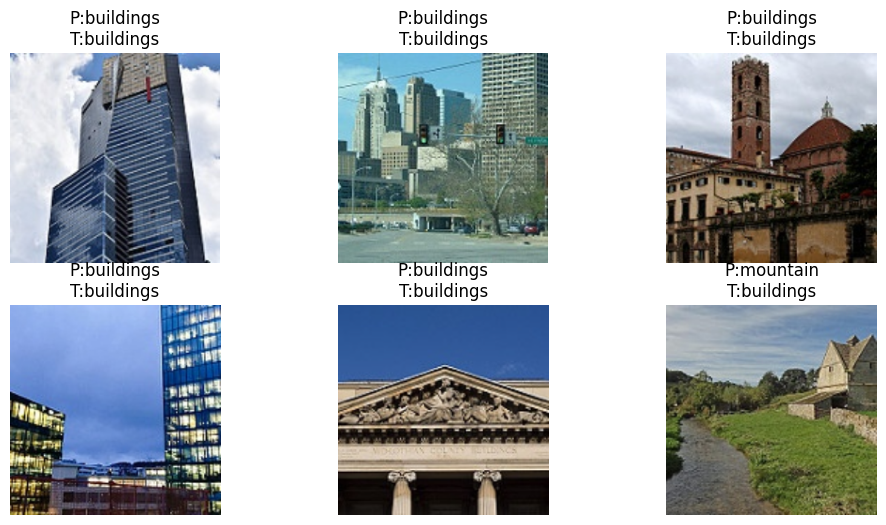

In [ ]:
def show_predictions():
    model.eval()
    images, labels = next(iter(test_loader))

    images = images.to(device)
    outputs = model(images)
    _, preds = torch.max(outputs, 1)

    images = images.cpu()

    plt.figure(figsize=(12,6))
    for i in range(6):
        plt.subplot(2,3,i+1)
        img = images[i].permute(1,2,0).numpy()

        img = img * np.array([0.229,0.224,0.225]) + np.array([0.485,0.456,0.406])
        img = np.clip(img, 0, 1)

        plt.imshow(img)
        plt.title(f"P:{class_names[preds[i]]}\nT:{class_names[labels[i]]}")
        plt.axis("off")

    plt.show()

show_predictions()